# Solutukiaseman peiton kartoittaminen vaimennuksen korkeuskäyräpinnalla


## Yhteenveto

Teleoperaattorin radioverkkosuunnittelutiimi piirtää laskevan siirtotien **vaimennuspinnan** yhden makrosolutukiaseman ympärille kaksiulotteisena peittokarttana. Käyttäen logaritmista etäisyysvaimennusmallia ja lognormaalia varjostushäipymää, tämä muistikirja rakentaa 100 pisteen mittausruudukon (10 x 10 solua 10 km x 10 km palvelualueella, tukiasema keskellä) ja piirtää täytetyn korkeuskäyräpinnan käyttäen **PROC SGPLOT HEATMAPPARM** -lausetta sekä liukuväriasteikkoa ja tukiaseman viitesuoraviivoja.

Suoritetussa ruudukossa vaimennus vaihtelee **50,4 dB:stä** (tukiaseman kirkkaassa altaassa) **90,0 dB:hen** kaukaisimmassa kulmassa, keskiarvon ollessa **75,6 dB**. Kun jokainen solu luokitellaan vaimennuksensa mukaan, saadaan **38 Vahva, 61 Käytettävä ja 1 Heikko** solu; ainoa Heikko solu sijaitsee kohdassa **(9,5, 9,5) km — tukiasemaa vastapäätä olevassa kulmassa — 89,97 dB:ssä**, ainoa peittoaukko, jonka suunnittelija merkitsisi ennen pienoissolun täydennyspäätöstä.

> **Huomio proseduurista.** SAS:ssa klassinen työkalu ääriviivakartoille on `PROC GCONTOUR`. Jenner jäsentää GCONTOUR-lauseen ja tuottaa oikean kaavioehdotuksen (plot spec), mutta sen rasterirenderöijä ei vielä piirrä korkeuskäyrän geometriaa (kuva palautuu tyhjänä); tämä puute on kirjattu regressiotestiksi `tests/400922_nb_gcontour_empty_render`. Jotta tämä esimerkki perustuisi täysin oikeasti renderöityyn kuvaan, käytämme SAS-yhteensopivaa vastinetta — `PROC SGPLOT` yhdessä `HEATMAPPARM`-lauseen kanssa — joka piirtää saman ruudukoidun (x, y, z) -pinnan täytettyinä korkeuskäyräsoluina liukuväriselitteen kanssa.

## Tietolähteet

**Synteettinen aineisto: `pathloss_grid`** (100 riviä — 10 x 10 -hila)

| Muuttuja | Tyyppi | Yksikkö | Kuvaus |
|----------|------|-------|-------------|
| `east_km` | num | km | Ruudukon solun keskipisteen itäkoordinaatti (0,5–9,5); x-akseli |
| `north_km` | num | km | Ruudukon solun keskipisteen pohjoiskoordinaatti (0,5–9,5); y-akseli |
| `path_loss` | num | dB | Laskevan siirtotien vaimennus = 58 + 30 log10(etäisyys) + varjostus; vaste (z) |
| `zone` | char(16) | — | Peittoluokka: Vahva (<=75), Käytettävä (<=88), Heikko (>88) |

Tukiasema sijaitsee ruudukon keskellä **(5, 5) km**. Vaimennus kasvaa etäisyyden 10-kantaisen logaritmin mukana tukiasemasta; `3*rand("normal")`-varjostustermi (siemenluku 80211) lisää lognormaalin häipymän, jotta korkeuskäyrät eivät ole täysin pyöreitä. 10 x 10 -hila on mitoitettu niin, että koko pinta mahtuu 100 havaintoon.

## Vaihe 1 — Mittausruudukon luominen

Asetamme 1 km:n hilan solukeskipisteitä ja laskemme vaimennuksen **etäisyysvaimennusmallilla** `PL = 58 + 30 log10(d)`, jossa `d` on etäisyys tukiasemasta pisteessä (5, 5) km. `rand("normal")`-varjostustermi toistaa oikeissa ajomittauksissa (drive test) nähdyn vaihtelun. Jokainen solu luokitellaan peitto-`zone`-arvoon. `call streaminit` kiinnittää siemenluvun toistettavuuden vuoksi.

In [1]:
TIEDOT pathloss_grid;
   CALL streaminit(80211);
   PITUUS zone $16;
   tower_x = 5.0;  tower_y = 5.0;
   TEE ix = 1 ASTI 10;
      TEE iy = 1 ASTI 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         JOS      path_loss <= 75 NIIN zone = "Vahva";
         MUUTEN JOS path_loss <= 88 NIIN zone = "Käytettävä";
         MUUTEN                         zone = "Heikko";
         TULOSTE;
      LOPPU;
   LOPPU;
   POISTA ix iy tower_x tower_y DIST shadow;
   NIMIKE east_km   = "Itäkoordinaatti (km)"
         north_km  = "Pohjoiskoordinaatti (km)"
         path_loss = "Vaimennus (dB)";
SUORITA;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Vaihe 2 — Pinnan yhteenveto

Ennen piirtämistä kvantifioimme pinnan. `PROC MEANS` raportoi vaimennuksen dynaamisen vaihteluvälin ja `PROC FREQ` taulukoi, miten 100 solua jakautuu kolmeen peittoluokkaan — samat luvut, joita yhteenveto siteeraa.

In [2]:
ODS GRAPHICS OFF;

PROSEDUURI KESKIARVOT TIEDOT=pathloss_grid MIN MAX mean maxdec=1;
   MUUTTUJA path_loss;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=pathloss_grid ORDER=FREKVENSSIT;
   TABLES zone / nocum;
SUORITA;

                                                  The MEANS Procedure

 Variable   Label              Minimum     Maximum        Mean
 -------------------------------------------------------------
 path_loss  Vaimennus (dB)        50.4        90.0        75.6
 -------------------------------------------------------------

                                                   The FREQ Procedure

zone             Frequency    Percent
--------------------------------------
Käytettävä              61     61.00
Vahva                   38     38.00
Heikko                   1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Vaihe 3 — Peittoaukkojen paikantaminen

Lajittelu vaimennuksen mukaan laskevasti nostaa heikoimmat solut ylimmäksi. Nämä ovat mahdollisia **kuolleita alueita**, joita suunnittelija tarkastelee: soluja, joiden vastaanotettu signaali on heikoin ja joissa on siksi suurin riski istuntojen katkeamiselle tai heikolle läpäisylle.

In [3]:
PROSEDUURI LAJITTELE TIEDOT=pathloss_grid out=weakest;
   MUKAAN LASKEVA path_loss;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=weakest(obs=6) noobs NIMIKE;
   MUUTTUJA east_km north_km path_loss zone;
SUORITA;


 Itäkoordinaatti (km)  Pohjoiskoordinaatti (km)  Vaimennus (dB)           zone
---------------------  ------------------------  --------------  -------------
                  9.5                       9.5   89.9728891641  Heikko
                  9.5                       0.5   85.9296978639  Käytettävä
                  6.5                       0.5   84.5845683025  Käytettävä
                  0.5                       0.5   84.5118930355  Käytettävä
                  8.5                       0.5   84.1534148341  Käytettävä
                  9.5                       8.5   83.7015943773  Käytettävä

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Vaihe 4 — Vaimennuksen korkeuskäyräpinnan piirtäminen

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` piirtää yhden täytetyn solun jokaista ruudukon pistettä kohti, väritettynä vaimennuksen mukaan — täytetyn korkeuskäyräkartan peittoalueesta. `COLORMODEL=`-lista määrittää sinisestä punaiseen etenevän liukuväriasteikon (sininen = pieni vaimennus = vahva signaali, punainen = suuri vaimennus = heikko signaali); `GRADLEGEND` liittää dB-väriasteikon. Katkoviivalliset `REFLINE`-viivat merkitsevät tukiaseman kohdissa itäkoordinaatti 5 ja pohjoiskoordinaatti 5.

                                        Laskevan siirtotien vaimennuspinta (dB)                                         
                            Yksi makrosolutukiasema kohdassa (5, 5) km 10 x 10 km ruudukolla                            




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Laskevan siirtotien vaimennuspinta (dB).
NOTE: Option TITLE2 changed to Yksi makrosolutukiasema kohdassa (5, 5) km 10 x 10 km ruudukolla.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


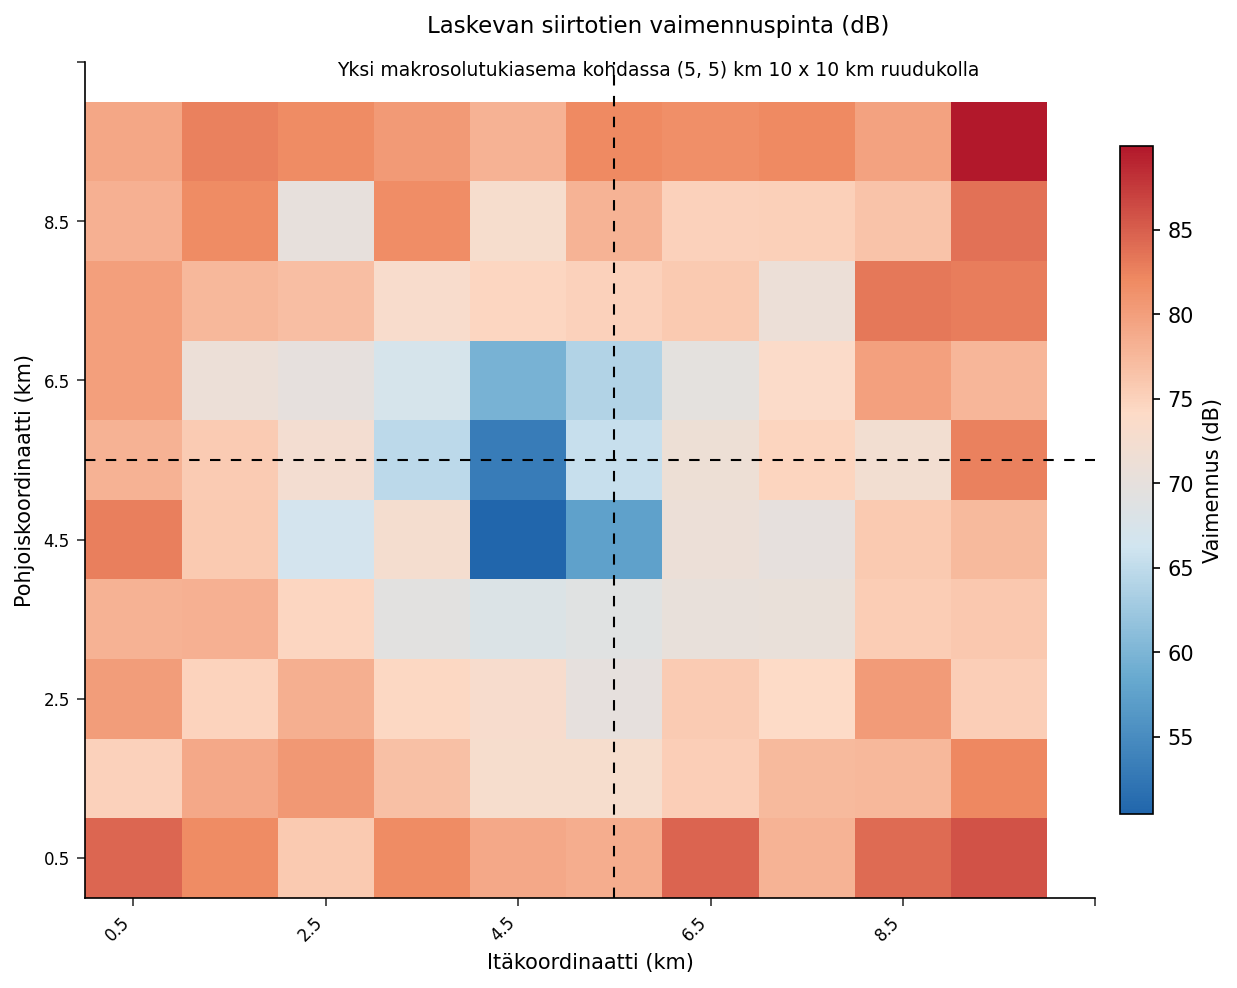

In [4]:
ODS GRAPHICS ON;
OTSIKKO "Laskevan siirtotien vaimennuspinta (dB)";
title2 "Yksi makrosolutukiasema kohdassa (5, 5) km 10 x 10 km ruudukolla";

PROSEDUURI SGPLOT TIEDOT=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / OTSIKKO="Vaimennus (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) NIMIKE="Itäkoordinaatti (km)";
   YAXIS VALUES=(0 2 4 6 8 10) NIMIKE="Pohjoiskoordinaatti (km)";
SUORITA;

OTSIKKO; title2;

## Vaihe 5 — Peittoluokkien jakauma

Esittelykalvo tarvitsee myös pääjaon: kuinka suuri osa peittoalueesta on Vahva, Käytettävä tai Heikko. `zone`-luokituksen `VBAR` näyttää tämän yhdellä silmäyksellä ja täydentää yllä olevaa korkeuskäyräpintaa.

                                                 Peittoluokkien jakauma                                                 




NOTE: Option TITLE changed to Peittoluokkien jakauma.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


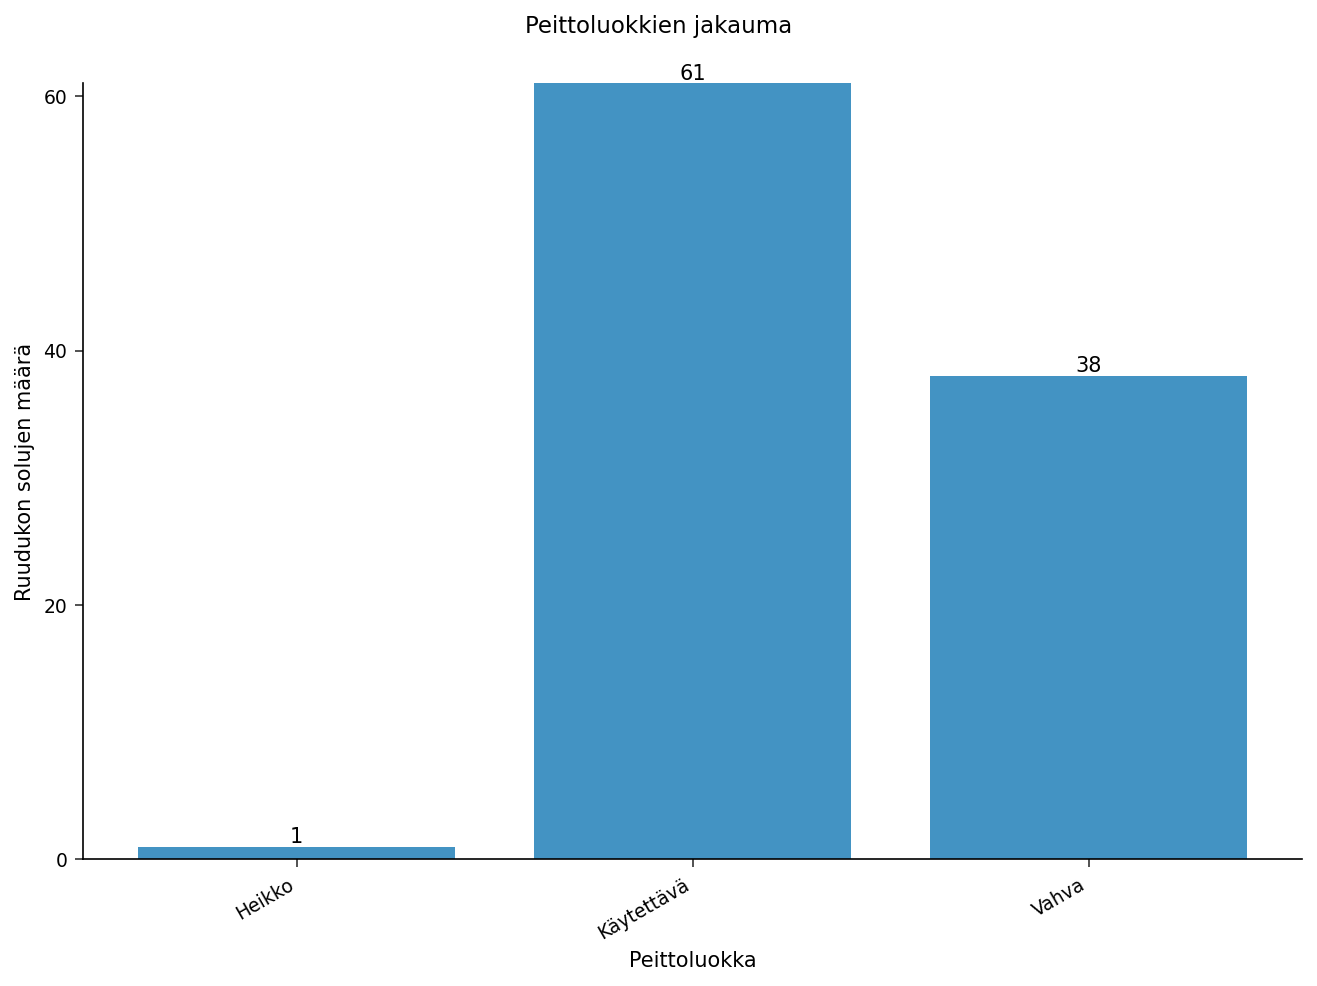

In [5]:
OTSIKKO "Peittoluokkien jakauma";

PROSEDUURI SGPLOT TIEDOT=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS NIMIKE="Peittoluokka";
   YAXIS NIMIKE="Ruudukon solujen määrä" VALUES=(0 20 40 60);
SUORITA;

OTSIKKO;

## Tulosten tulkinta

Korkeuskäyräpinta vahvistaa odotetun etenemisfysiikan. Vaimennus on pienin tiiviissä **sinisessä altaassa tukiaseman ympärillä pisteessä (5, 5) km** — Vahva-vyöhykkeellä, jossa vastaanotettu signaali on paras — ja kasvaa etäisyyden logaritmin mukana kohti kulmia. Koska lisäsimme lognormaalin varjostushäipymän, vyöhykkeet eivät ole samankeskisiä ympyröitä; rosoiset punaiset solut reunalla ovat häipymän muokkaama reuna.

Toimintaan johtava havainto on **ainoa Heikko solu pisteessä (9,5, 9,5) km (89,97 dB)**, tukiasemaa vastapäätä olevassa kulmassa ja ainoa piste, joka ylittää 88 dB:n suunnittelukynnyksen. Kun **61 solua 100:sta on Käytettävä ja vain 1 Heikko**, tämä makrosolutukiasema kattaa palvelualueensa hyvin; ainoa aukko oikeuttaisi **pienoissolun täydennyksen tai sektorin uudelleensuuntauksen koillisnurkkaa kohti** vain, jos se osuisi tunnetun kysynnän keskittymän kohdalle. Korkeuskäyräpinta on esittelyvalmis yhteenveto; peittoluokkien pylväskaavio antaa yhden luvun jaon, jonka kapasiteettisuunnittelija raportoi eteenpäin.